/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_54396/1514702900.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set1', n_clusters)


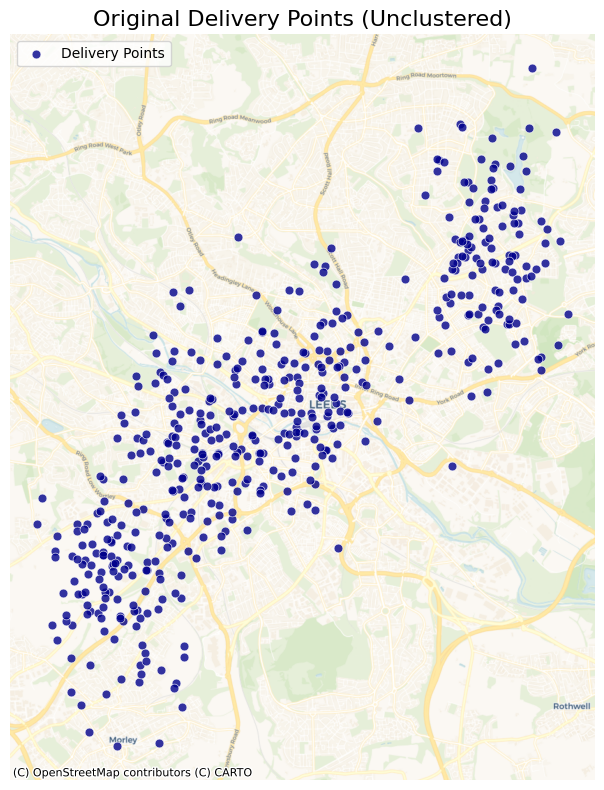

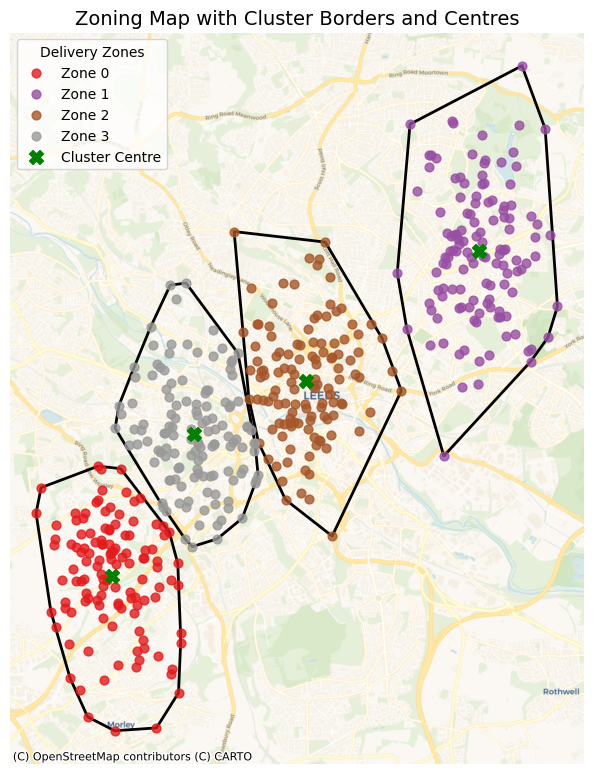

In [18]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, MultiPoint
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import contextily as ctx
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- Generate synthetic delivery data ---
n_clusters = 4
n_samples = 500
centers = [
    [53.8008, -1.5491],
    [53.8200, -1.5000],
    [53.7700, -1.6000],
    [53.7900, -1.5800],
]
X, _ = make_blobs(n_samples=n_samples, centers=centers, cluster_std=0.01, random_state=42)
df = pd.DataFrame(X, columns=['latitude', 'longitude'])
df['demand_volume'] = np.random.poisson(lam=n_clusters, size=n_samples)

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']), crs='EPSG:4326')
gdf = gdf.to_crs(epsg=3857)  # Web Mercator for mapping with contextily

# Apply KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
gdf['zone'] = kmeans.fit_predict(df[['latitude', 'longitude']])

# Create convex hulls for each zone
hulls = []
for cluster_id in gdf['zone'].unique():
    points = gdf[gdf['zone'] == cluster_id]
    if len(points) >= 3:
        hull = MultiPoint(points.geometry.values).convex_hull
        hulls.append({'geometry': hull, 'zone': cluster_id})
hulls_gdf = gpd.GeoDataFrame(hulls, crs=gdf.crs)

# Get cluster centres and convert to GeoDataFrame
centres_latlon = kmeans.cluster_centers_
centres_df = pd.DataFrame(centres_latlon, columns=['latitude', 'longitude'])
centres_gdf = gpd.GeoDataFrame(
    centres_df, 
    geometry=gpd.points_from_xy(centres_df['longitude'], centres_df['latitude']), 
    crs='EPSG:4326'
).to_crs(epsg=3857)

# Set up custom colour map
cmap = cm.get_cmap('Set1', n_clusters)
norm = mcolors.Normalize(vmin=0, vmax=n_clusters - 1)

# --- Plotting - Points without Clustering ---
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all delivery points
# Using a single color as they are not clustered yet
ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    s=40,
    color='darkblue',  # Choose a distinct color for the unclustered points
    edgecolors='white', # Add white edge for better visibility
    linewidth=0.5,
    alpha=0.8,
    label='Delivery Points'
)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)

# Set title and formatting
ax.set_title("Original Delivery Points (Unclustered)", fontsize=16)
ax.legend(loc='upper left', frameon=True) # Add a legend for clarity
ax.set_axis_off() # Turn off axis ticks and labels
ax.set_aspect('equal') # Ensure correct aspect ratio for map
plt.tight_layout() # Adjust layout to prevent labels/titles from overlapping
plt.show()

# --- Plotting clustered points ---
fig, ax = plt.subplots(figsize=(10, 8))

# Plot convex hulls
hulls_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2, linestyle='-')

# Plot delivery points with colour-matched edges
for cluster in range(n_clusters):
    cluster_data = gdf[gdf['zone'] == cluster]
    colour = cmap(cluster)
    ax.scatter(
        cluster_data.geometry.x,
        cluster_data.geometry.y,
        s=40,
        c=[colour],
        edgecolors=[colour],
        label=f'Zone {cluster}',
        alpha=0.8,
        linewidth=1
    )

# Plot cluster centres as green dots
centres_gdf.plot(ax=ax, marker='X', color='green', markersize=100, label='Cluster Centre')

# Add basemap and final touches
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)

ax.set_title("Zoning Map with Cluster Borders and Centres", fontsize=14)
ax.legend(title='Delivery Zones')
ax.set_axis_off()
ax.set_aspect
plt.tight_layout()
plt.savefig("leeds_zoning_map_with_cluster_centres.png", dpi=300)
plt.show()

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_54396/3012379636.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', len(unique_labels))


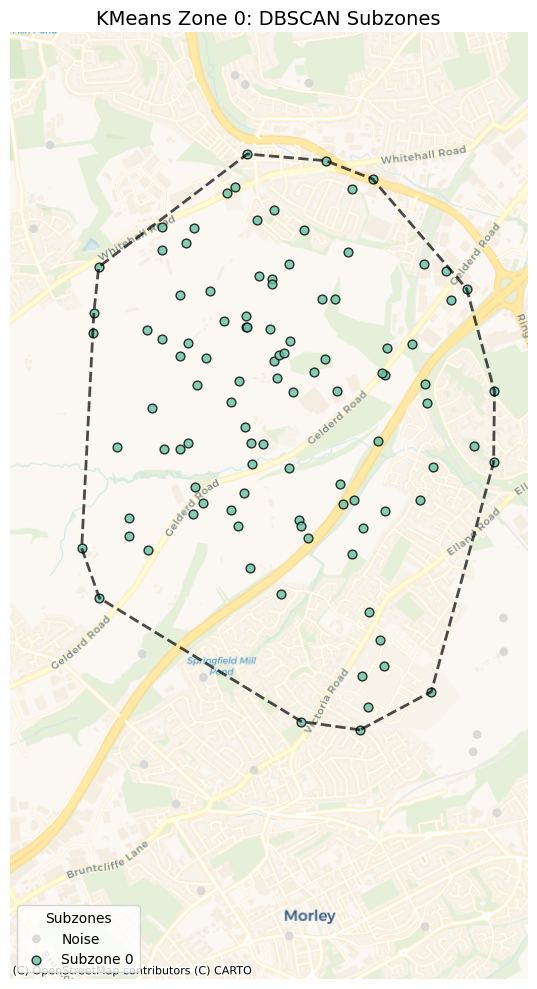

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_54396/3012379636.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', len(unique_labels))


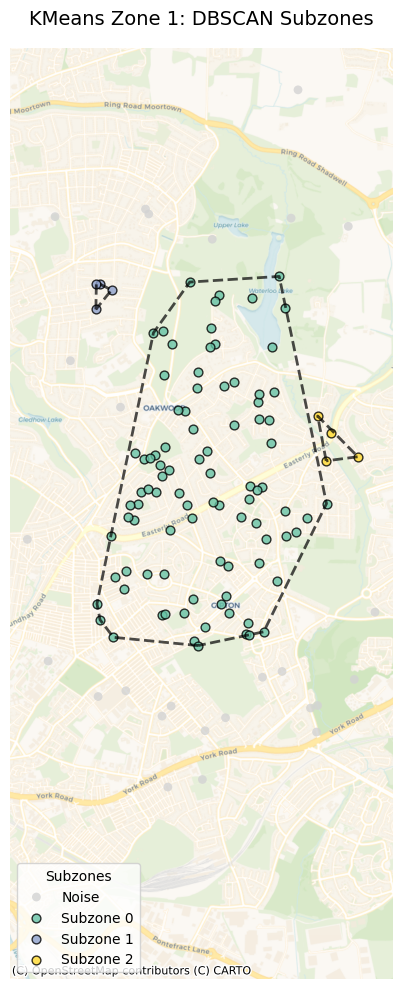

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_54396/3012379636.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', len(unique_labels))


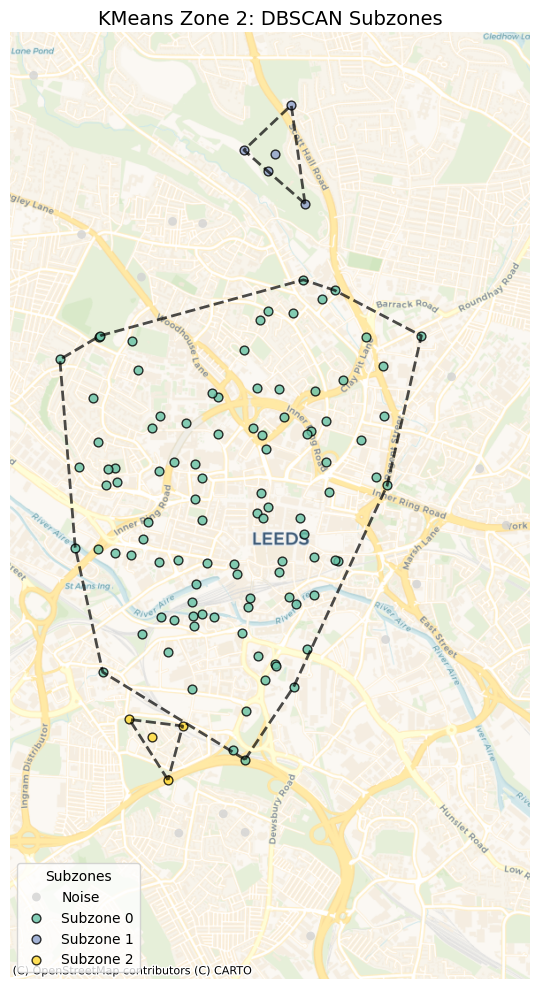

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_54396/3012379636.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', len(unique_labels))


KeyboardInterrupt: 

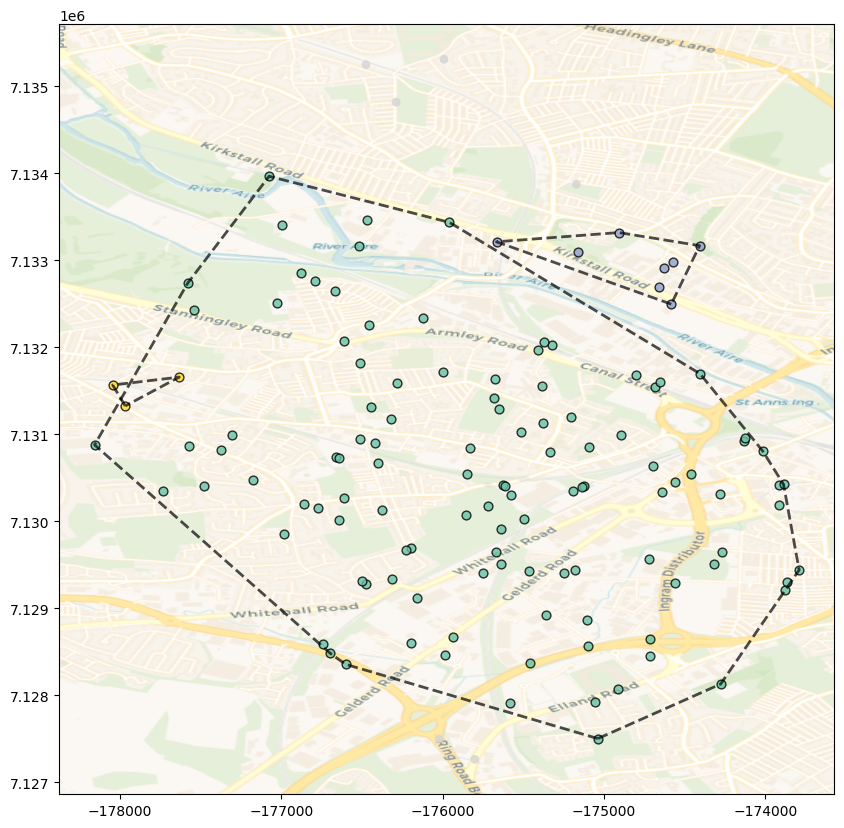

In [19]:
from sklearn.cluster import DBSCAN
from shapely.geometry import MultiPoint
import matplotlib.patches as patches

# DBSCAN parameters
db_eps = 600  # metres
db_min_samples = 4

for zone_id in range(n_clusters):
    # Subset the data for this KMeans zone
    sub_gdf = gdf[gdf['zone'] == zone_id].copy()

    # Extract coordinates (Web Mercator)
    coords = np.vstack([sub_gdf.geometry.x, sub_gdf.geometry.y]).T

    # Apply DBSCAN
    db = DBSCAN(eps=db_eps, min_samples=db_min_samples)
    sub_gdf['subzone'] = db.fit_predict(coords)

    # Colour map for subzones
    unique_labels = sorted(sub_gdf['subzone'].unique())
    sub_cmap = cm.get_cmap('Set2', len(unique_labels))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 10))

    for label in unique_labels:
        cluster_data = sub_gdf[sub_gdf['subzone'] == label]
        colour = 'lightgrey' if label == -1 else sub_cmap(label)

        # Plot points
        ax.scatter(
            cluster_data.geometry.x,
            cluster_data.geometry.y,
            s=40,
            c=[colour],
            edgecolors='k' if label != -1 else 'none',
            label=f'Subzone {label}' if label != -1 else 'Noise',
            alpha=0.8
        )

        # Add convex hull ring if not noise
        if label != -1 and len(cluster_data) >= 3:
            hull = MultiPoint(cluster_data.geometry.values).convex_hull
            if hull.geom_type == 'Polygon':
                xs, ys = hull.exterior.xy
                ax.plot(xs, ys, color='black', linewidth=2, linestyle='--', alpha=0.7)

    # Basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)

    # Title and formatting
    ax.set_title(f"KMeans Zone {zone_id}: DBSCAN Subzones", fontsize=14)
    ax.legend(title="Subzones", loc='lower left')
    ax.set_axis_off()
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_54396/2645571963.py:158: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', num_subzones_for_cmap)


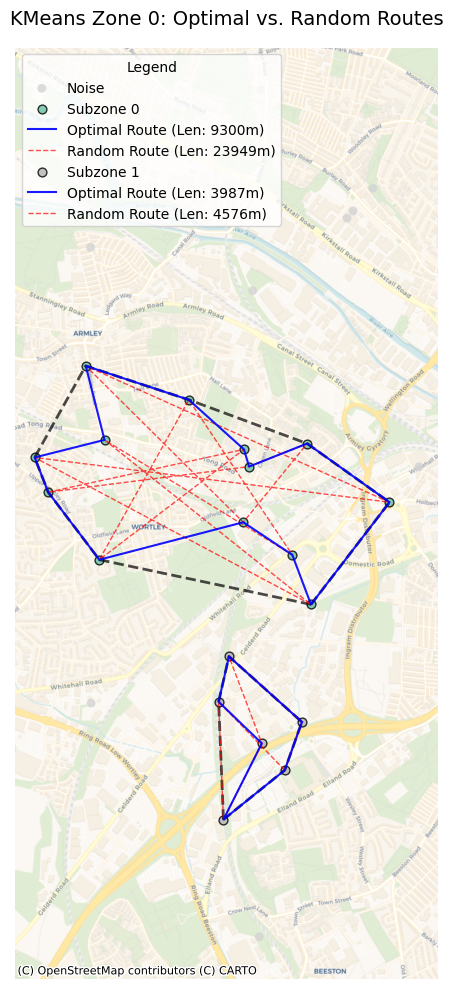

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_54396/2645571963.py:158: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', num_subzones_for_cmap)


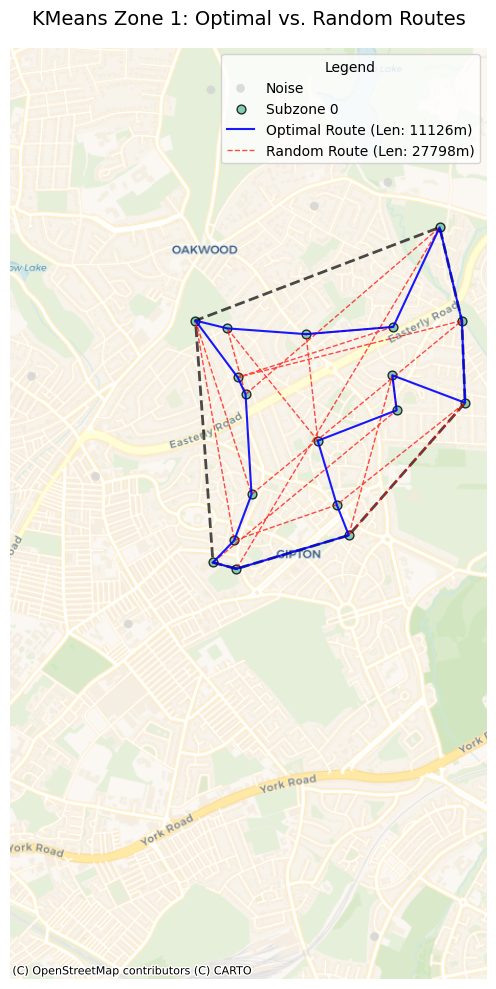

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_54396/2645571963.py:158: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', num_subzones_for_cmap)


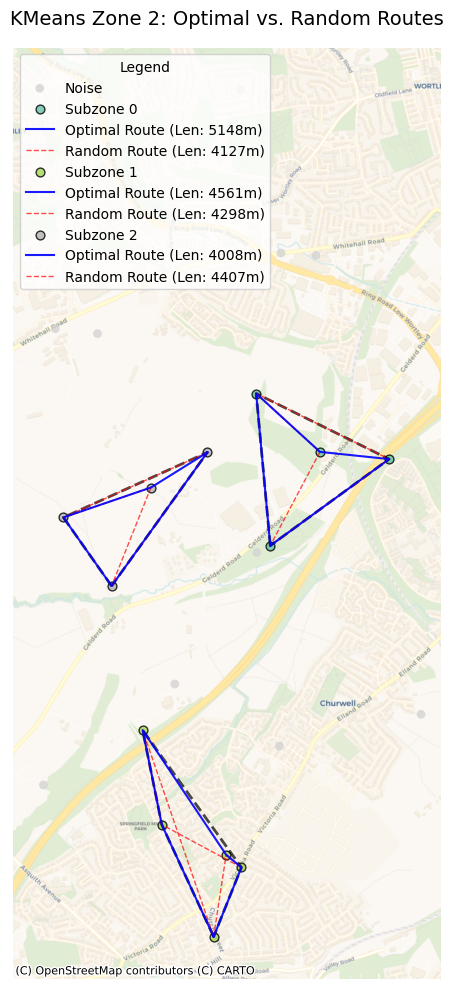

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_54396/2645571963.py:158: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', num_subzones_for_cmap)


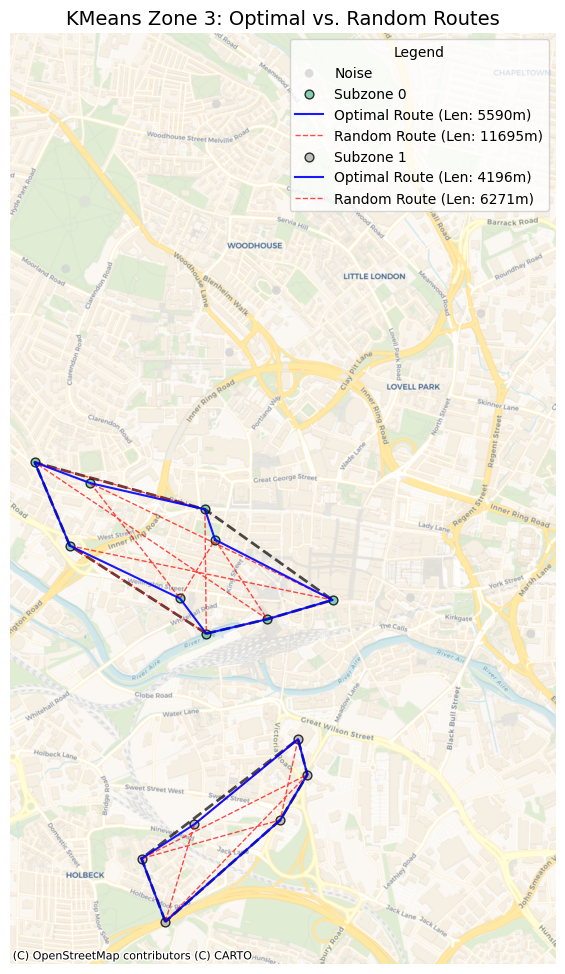

In [24]:
from sklearn.cluster import DBSCAN
from shapely.geometry import MultiPoint, LineString, Point
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
import matplotlib.cm as cm
import pandas as pd
import geopandas as gpd
import random # Import for random operations

# Import for generating sample data
from sklearn.datasets import make_blobs

# Import for TSP solving - PuLP
from pulp import *

# DBSCAN parameters
db_eps = 900  # metres
db_min_samples = 4

# --- Function to calculate Euclidean distance (for simplicity) ---
def euclidean_distance(point1, point2):
    return np.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

# --- TSP Solver using PuLP (simpler for smaller numbers of points) ---
def solve_tsp_pulp(points):
    num_points = len(points)
    if num_points <= 1:
        return list(range(num_points)), 0.0

    # Create a list of all distances
    distances = {}
    for i in range(num_points):
        for j in range(num_points):
            distances[(i, j)] = euclidean_distance(points[i], points[j])

    # Define the problem
    prob = LpProblem("TSP", LpMinimize)

    # Decision variables
    x = LpVariable.dicts("x", (range(num_points), range(num_points)), 0, 1, LpBinary)
    u = LpVariable.dicts("u", range(num_points), 0, num_points - 1, LpInteger)

    # Objective function: Minimize total distance
    prob += lpSum(distances[(i, j)] * x[i][j] for i in range(num_points) for j in range(num_points) if i != j)

    # Constraints:
    # 1. Each node must have exactly one incoming edge
    for j in range(num_points):
        prob += lpSum(x[i][j] for i in range(num_points) if i != j) == 1

    # 2. Each node must have exactly one outgoing edge
    for i in range(num_points):
        prob += lpSum(x[i][j] for j in range(num_points) if i != j) == 1

    # 3. Sub-tour elimination constraints (Miller-Tucker-Zemlin formulation)
    for i in range(num_points):
        for j in range(num_points):
            if i != j and (i != 0 and j != 0): # Exclude constraints for starting node (node 0)
                prob += u[i] - u[j] + num_points * x[i][j] <= num_points - 1

    # Solve the problem
    prob.solve(PULP_CBC_CMD(msg=0)) # Use CBC solver, set msg=0 to suppress output

    # Extract the route
    route = []
    current_node = 0
    start_node = 0
    total_length = 0.0
    while True:
        route.append(current_node)
        found_next = False
        for j in range(num_points):
            if current_node != j and x[current_node][j].varValue == 1:
                total_length += distances[(current_node, j)]
                current_node = j
                found_next = True
                break
        if not found_next or current_node == start_node:
            break
    # Ensure the route closes the loop if it's a full TSP
    if len(route) == num_points and route[0] != route[-1]:
        route.append(route[0])
        total_length += distances[(route[-2], route[-1])] # Add distance back to start

    return route, total_length

# --- Function to calculate the length of a given route (sequence of points) ---
def calculate_route_length(points, route_indices):
    if len(route_indices) < 2:
        return 0.0
    
    total_length = 0.0
    # Iterate through the route segments, including return to start
    for i in range(len(route_indices) - 1):
        p1_idx = route_indices[i]
        p2_idx = route_indices[i+1]
        total_length += euclidean_distance(points[p1_idx], points[p2_idx])
        
    # If it's a closed loop TSP, add the distance from the last point back to the start
    if route_indices[0] != route_indices[-1]: # If the route is not already closed
        total_length += euclidean_distance(points[route_indices[-1]], points[route_indices[0]])
        
    return total_length


# --- Data Generation using make_blobs (your provided setup) ---
n_samples = 100 # Example number of samples
n_clusters = 4  # Example number of clusters (for KMeans initial grouping, before DBSCAN)

centers = [
    [53.8008, -1.5491],
    [53.8200, -1.5000],
    [53.7700, -1.6000],
    [53.7900, -1.5800],
]
X, _ = make_blobs(n_samples=n_samples, centers=centers, cluster_std=0.01, random_state=42)
df = pd.DataFrame(X, columns=['latitude', 'longitude'])
df['demand_volume'] = np.random.poisson(lam=n_clusters, size=n_samples)

# --- KMeans Zoning ---
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
df['zone'] = kmeans.fit_predict(X)

# --- Create 'geometry' column and convert to GeoDataFrame ---
df['geometry'] = df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# --- Reproject to Web Mercator for accurate distance calculations and plotting with contextily ---
gdf = gdf.to_crs(epsg=3857)

# Now, extract x and y after re-projection (used for DBSCAN and TSP)
gdf['x'] = gdf.geometry.x
gdf['y'] = gdf.geometry.y


for zone_id in range(n_clusters):
    # Subset the data for this KMeans zone
    sub_gdf = gdf[gdf['zone'] == zone_id].copy()

    if sub_gdf.empty:
        print(f"KMeans Zone {zone_id} is empty, skipping.")
        continue

    # Extract coordinates (Web Mercator) for DBSCAN
    coords = np.vstack([sub_gdf.geometry.x, sub_gdf.geometry.y]).T

    # Apply DBSCAN
    db = DBSCAN(eps=db_eps, min_samples=db_min_samples)
    sub_gdf['subzone'] = db.fit_predict(coords)

    # Colour map for subzones
    unique_labels = sorted(sub_gdf['subzone'].unique())
    num_subzones_for_cmap = len([l for l in unique_labels if l != -1])
    if num_subzones_for_cmap > 0:
        sub_cmap = cm.get_cmap('Set2', num_subzones_for_cmap)
    else:
        sub_cmap = cm.get_cmap('Set2', 1) # Fallback if only noise or no clusters

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 10))

    # Store handles for legend
    legend_handles = []

    # Map actual subzone labels to sequential color indices for the colormap
    subzone_label_to_cmap_idx = {label: i for i, label in enumerate(l for l in unique_labels if l != -1)}


    for label_idx, label in enumerate(unique_labels):
        cluster_data = sub_gdf[sub_gdf['subzone'] == label].copy()
        
        if cluster_data.empty:
            continue

        if label == -1:
            colour = 'lightgrey'
            label_text = 'Noise'
            edgecolor = 'none'
        else:
            colour = sub_cmap(subzone_label_to_cmap_idx.get(label, 0)) # Use mapped index
            label_text = f'Subzone {label}'
            edgecolor = 'k'

        # Plot points
        scatter = ax.scatter(
            cluster_data.geometry.x,
            cluster_data.geometry.y,
            s=40,
            c=[colour],
            edgecolors=edgecolor,
            label=label_text,
            alpha=0.8
        )
        # Add scatter handle to legend list
        legend_handles.append(scatter)

        # Add convex hull ring if not noise and enough points
        if label != -1 and len(cluster_data) >= 3:
            hull = MultiPoint(cluster_data.geometry.to_list()).convex_hull
            if hull.geom_type == 'Polygon':
                xs, ys = hull.exterior.xy
                ax.plot(xs, ys, color='black', linewidth=2, linestyle='--', alpha=0.7)

            # --- ROUTE OPTIMIZATION AND PLOTTING ---
            if len(cluster_data) > 1: # Need at least 2 points for a route
                # Ensure the points for TSP are the reprojected (x, y)
                cluster_points = cluster_data[['x', 'y']].values.tolist()
                num_cluster_points = len(cluster_points)

                # --- Plot Optimal Route (Blue) ---
                optimized_route_indices, total_route_length = solve_tsp_pulp(cluster_points)

                if optimized_route_indices:
                    optimized_coords = [cluster_points[i] for i in optimized_route_indices]
                    route_line_optimal = LineString(optimized_coords)
                    xs_optimal, ys_optimal = route_line_optimal.xy
                    route_plot_optimal, = ax.plot(xs_optimal, ys_optimal,
                                          color='blue',
                                          linewidth=1.5,
                                          linestyle='-',
                                          alpha=0.9,
                                          zorder=3,
                                          label=f'Optimal Route (Len: {total_route_length:.0f}m)')
                    legend_handles.append(route_plot_optimal)
                
                # --- Plot Random Route (Red) ---
                if num_cluster_points > 1: # Need at least 2 points for a route
                    random_route_indices = list(range(num_cluster_points))
                    # Shuffle the indices to create a random route
                    random.shuffle(random_route_indices)
                    # Ensure the random route returns to the start
                    if random_route_indices[0] != random_route_indices[-1]:
                        random_route_indices.append(random_route_indices[0]) # Close the loop

                    # Calculate the length of the random route
                    total_random_length = 0.0
                    if len(random_route_indices) > 1:
                        # Iterate through the random route segments, including return to start
                        # The calculate_route_length function already handles this
                        total_random_length = calculate_route_length(cluster_points, random_route_indices)

                    # Map indices back to original coordinates to form the random route line
                    random_coords = [cluster_points[i] for i in random_route_indices]
                    
                    if len(random_coords) > 1: # Ensure we have enough points to form a line
                        route_line_random = LineString(random_coords)
                        xs_random, ys_random = route_line_random.xy
                        route_plot_random, = ax.plot(xs_random, ys_random,
                                              color='red', # Red color for the random route
                                              linewidth=1.0, # Slightly thinner to differentiate
                                              linestyle='--', # Dashed line for random
                                              alpha=0.7,
                                              zorder=2, # Below optimal, but above points
                                              label=f'Random Route (Len: {total_random_length:.0f}m)')
                        legend_handles.append(route_plot_random)


    # Basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)

    # Title and formatting
    ax.set_title(f"KMeans Zone {zone_id}: Optimal vs. Random Routes", fontsize=14)

    # Refined legend placement: to the right of the plot
    ax.legend(handles=legend_handles, title="Legend", loc='best')
    
    ax.set_axis_off()
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()